# Game 6 - The Optimization Decathlon

**Team:** Ded_Sec

Each experiment changes one major factor. Failed experiments remain in the
history and are explicitly rejected.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path.cwd()
experiments = pd.read_csv(OUTPUT_DIR / "optimization_experiments.csv")
best = pd.read_csv(OUTPUT_DIR / "best_models_summary.csv")

display(experiments)
display(best)


,experiment_id,modality,base_model,hypothesis,change_applied,accuracy,macro_f1,precision,recall,training_time,inference_time,decision,reason
0,I00,image,scratch_image_cnn,The Game 4 checkpoint is the strongest honest ...,none,0.8428,0.842209,0.848014,0.8428,338.972385,32.687364,accepted,Reference baseline.
1,I01,image,scratch_image_cnn,Horizontal-flip TTA will reduce orientation-se...,average original and horizontal-flip probabili...,0.8424,0.841784,0.847817,0.8424,0.000000,42.382842,rejected,No meaningful gain for doubled inference cost.
2,I02,image,scratch_image_cnn,Mild label smoothing will reduce overconfidenc...,CrossEntropy label_smoothing=0.05,0.8328,0.832388,0.836108,0.8328,225.708575,8.588623,rejected,Did not beat the baseline by the acceptance ma...
3,I03,image,scratch_image_cnn,Increasing input size from 128 to 160 will pre...,image_size=160,0.8496,0.849319,0.852229,0.8496,233.476281,8.035016,accepted,Improved validation macro-F1.
4,T00,text,minilm_frozen_embeddings_logreg,Reference MiniLM logistic classifier.,none,0.7648,0.764571,0.765835,0.7648,3.739620,0.880794,accepted,Reference baseline.
5,T01,text,minilm_frozen_embeddings_logreg,Stronger regularization may improve generaliza...,logistic C=0.25,0.7496,0.749215,0.751144,0.7496,3.680922,0.882318,rejected,Did not beat the baseline by the acceptance ma...
6,T02,text,minilm_frozen_embeddings_logreg,Weaker regularization may fit the task boundar...,logistic C=4.0,0.7648,0.764626,0.765586,0.7648,3.735162,0.883685,rejected,Did not beat the baseline by the acceptance ma...
7,T03,text,minilm_frozen_embeddings_logreg,Removing class weights may help because valida...,class_weight=None,0.7532,0.753127,0.753500,0.7532,3.698441,0.882653,rejected,Did not beat the baseline by the acceptance ma...
8,T04,text,minilm_frozen_embeddings_logreg,Text length and missingness may add useful rel...,append standardized text length and missing-te...,0.7676,0.767443,0.768326,0.7676,3.951688,0.878793,accepted,Improved validation macro-F1.


,modality,selected_model,baseline_macro_f1,final_macro_f1,macro_f1_gain,training_time,inference_time,selection_reason
0,image,ScratchImageCNN/I03,0.842209,0.849319,0.007110,233.476281,8.035016,160-pixel input
1,text,MiniLMLogReg/T04,0.764571,0.767443,0.002872,3.951688,0.878793,Highest measured validation macro-F1 among con...


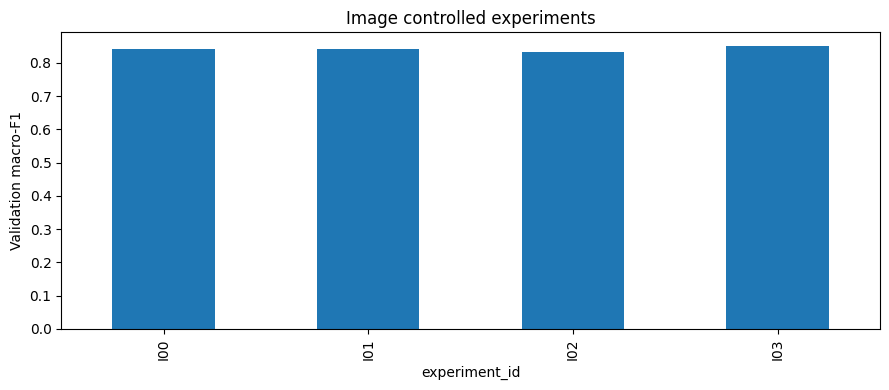

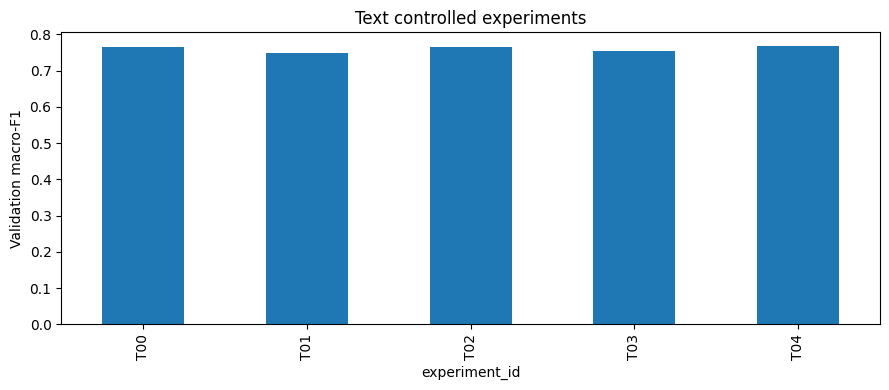

experiments
modality decision             
image    accepted            2
         rejected            2
text     accepted            2
         rejected            3

In [2]:
for modality, group in experiments.groupby("modality"):
    group.plot.bar(
        x="experiment_id",
        y="macro_f1",
        figsize=(9, 4),
        title=f"{modality.title()} controlled experiments",
        legend=False,
    )
    plt.ylabel("Validation macro-F1")
    plt.tight_layout()
    plt.show()

display(
    experiments.groupby(["modality", "decision"])
    .size()
    .to_frame("experiments")
)


## Final Conclusion

Selected image experiment I03 with macro-F1=0.8493 versus baseline 0.8422. Selected text experiment T04 with macro-F1=0.7674 versus baseline 0.7646. Accepted experiments: ['I00', 'I03', 'T00', 'T04']. Rejected experiments: ['I01', 'I02', 'T01', 'T02', 'T03']. Every rejected result is retained because optimization decisions were based on measured macro-F1 and cost rather than selective reporting.
